In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../outputs/customer_rfm.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nKey column stats:")
print(df[['Recency','Frequency','Monetary','CLTV','Churn_Probability']].describe().round(2))

Shape: (4228, 25)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AOV', 'UniqueProducts', 'Lifespan', 'AvgDaysBetweenOrders', 'CLTV', 'CLTV_Tier', 'Churned', 'Log_Recency', 'Log_Frequency', 'Log_Monetary', 'Log_AOV', 'Log_CLTV', 'F_Score', 'M_Score', 'R_Score', 'RFM_Score', 'RFM_Label', 'Segment', 'Churn Probability', 'Churn_Probability', 'Churn_Risk']

Key column stats:
       Recency  Frequency   Monetary     CLTV  Churn_Probability
count  4228.00    4228.00    4228.00  4228.00            4228.00
mean     92.60       4.09    1255.86   140.31               0.33
std     100.23       7.19    2812.55   377.15               0.20
min       1.00       1.00       2.90     1.45               0.05
25%      18.00       1.00     250.16    17.24               0.15
50%      51.00       2.00     563.19    45.62               0.36
75%     143.25       4.00    1351.11   123.22               0.53
max     374.00     201.00  105017.20  8125.26               0.61


In [72]:
from sklearn.preprocessing import StandardScaler

CLUSTER_FEATURES=[
    'Recency', 'Frequency', 'Monetary',
    'AOV', 'UniqueProducts', 'Lifespan',
    'CLTV', 'Churn_Probability'
]

X_cluster=df[CLUSTER_FEATURES].fillna(0)

scaler_kmeans=StandardScaler()
X_scaled=scaler_kmeans.fit_transform(X_cluster)
X_scaled_df=pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES, index=df.index)

print("Clustering feature matrix shape:", X_scaled.shape)
print("\nScaled feature sample:")
print(X_scaled_df.head())

Clustering feature matrix shape: (4228, 8)

Scaled feature sample:
    Recency  Frequency  Monetary       AOV  UniqueProducts  Lifespan  \
0 -0.903982   0.404644  0.898710  0.121181        0.506210  1.790789   
1  1.560644  -0.151454 -0.414500 -0.237831       -0.656607 -0.153828   
2 -0.734352  -0.429503  0.025847  0.012398        0.102284 -0.981809   
3  2.169318  -0.429503 -0.341888 -0.050796       -0.534205 -0.981809   
4 -0.564722   0.404644  0.023514 -0.093766       -0.044598  0.993193   

       CLTV  Churn_Probability  
0  0.425964          -1.449020  
1 -0.216751           0.859431  
2 -0.320252           0.330707  
3 -0.323268           1.113975  
4  0.188200          -1.099730  


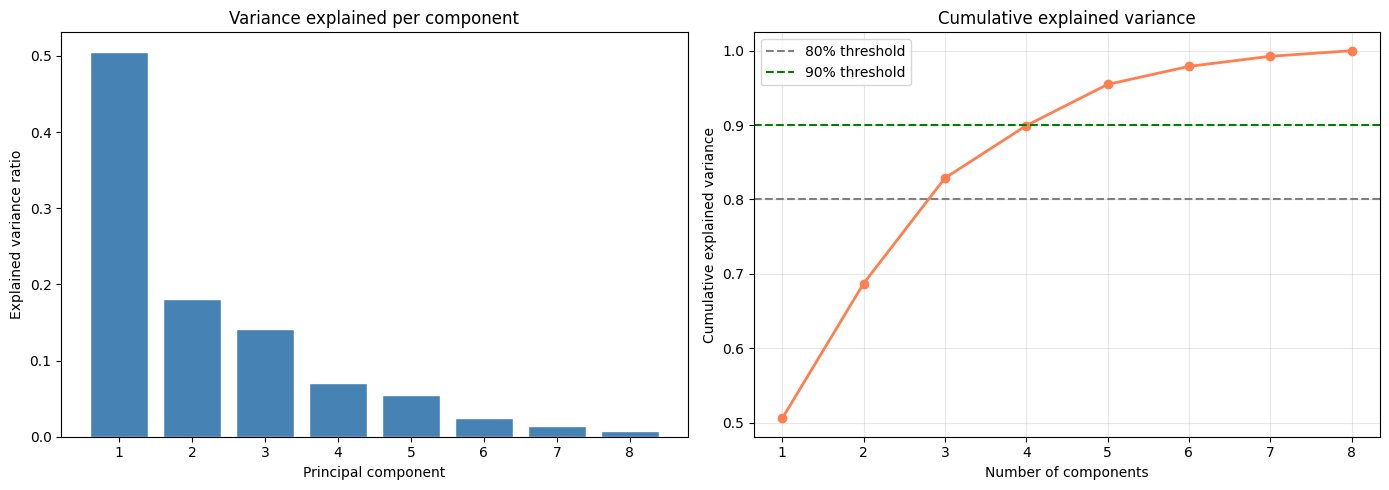

PC1: 0.506 individual, 0.506 cumulative
PC2: 0.181 individual, 0.687 cumulative
PC3: 0.142 individual, 0.829 cumulative
PC4: 0.071 individual, 0.899 cumulative
PC5: 0.055 individual, 0.955 cumulative
PC6: 0.024 individual, 0.979 cumulative
PC7: 0.014 individual, 0.993 cumulative
PC8: 0.007 individual, 1.000 cumulative


In [73]:
from sklearn.decomposition import PCA

pca_full=PCA(random_state=42)
pca_full.fit(X_scaled)

explained=pca_full.explained_variance_ratio_
cumulative=np.cumsum(explained)

fig, axes=plt.subplots(1,2,figsize=(14,5))

axes[0].bar(range(1, len(explained)+1), explained,color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Variance explained per component')

axes[1].plot(range(1, len(cumulative)+1), cumulative,marker='o', color='coral', linewidth=2)
axes[1].axhline(0.80, color='gray', linestyle='--', label='80% threshold')
axes[1].axhline(0.90, color='green', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative explained variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/pca_explained_variance.png', dpi=100, bbox_inches='tight')
plt.show()

for i, (ev, cv) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i}: {ev:.3f} individual, {cv:.3f} cumulative")


In [74]:
N_COMPONENTS=2
pca=PCA(n_components=N_COMPONENTS, random_state=42)
X_pca=pca.fit_transform(X_scaled)

print(f"\nUsing {N_COMPONENTS} components")
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")


Using 2 components
Variance explained: 68.7%
PC1: 50.6%
PC2: 18.1%



PCA loadings (how much each feature contributes to each component):
                     PC1    PC2
Recency           -0.266  0.414
Frequency          0.425  0.264
Monetary           0.407  0.319
AOV                0.017  0.471
UniqueProducts     0.386 -0.033
Lifespan           0.390 -0.331
CLTV               0.356  0.426
Churn_Probability -0.394  0.379


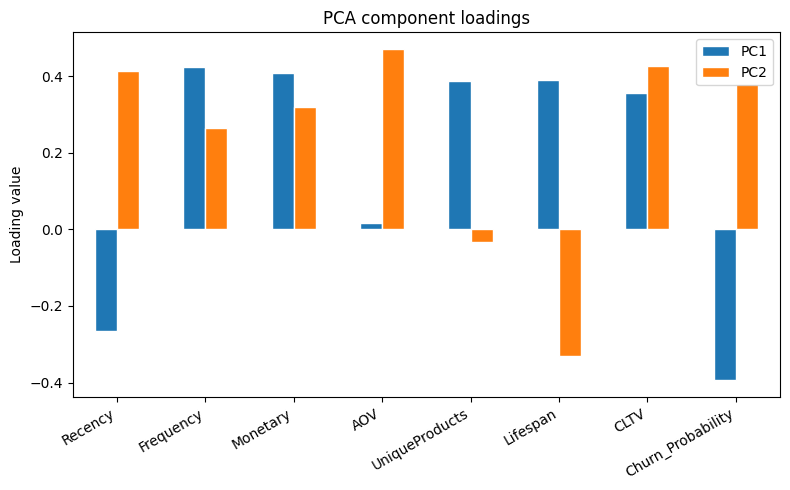

In [75]:
loadings=pd.DataFrame(pca.components_.T,index=CLUSTER_FEATURES,columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]).round(3)

print("\nPCA loadings (how much each feature contributes to each component):")
print(loadings)

plt.figure(figsize=(8, 5))
loadings.plot(kind='bar', ax=plt.gca(), edgecolor='white')
plt.title('PCA component loadings')
plt.ylabel('Loading value')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/pca_loadings.png', dpi=100, bbox_inches='tight')
plt.show()

In [76]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias=[]
silhouettes=[]
K_RANGE=range(2,11)

for k in K_RANGE:
    km=KMeans(n_clusters=k, random_state=42, n_init=10)
    labels=km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca,labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={silhouette_score(X_pca, labels):.4f}")

k=2: inertia=13378.5, silhouette=0.5308
k=3: inertia=8585.1, silhouette=0.5419
k=4: inertia=6399.8, silhouette=0.5178
k=5: inertia=5022.1, silhouette=0.4378
k=6: inertia=3926.9, silhouette=0.4390
k=7: inertia=3264.9, silhouette=0.4133
k=8: inertia=2736.8, silhouette=0.4121
k=9: inertia=2363.3, silhouette=0.4154
k=10: inertia=2075.3, silhouette=0.4046


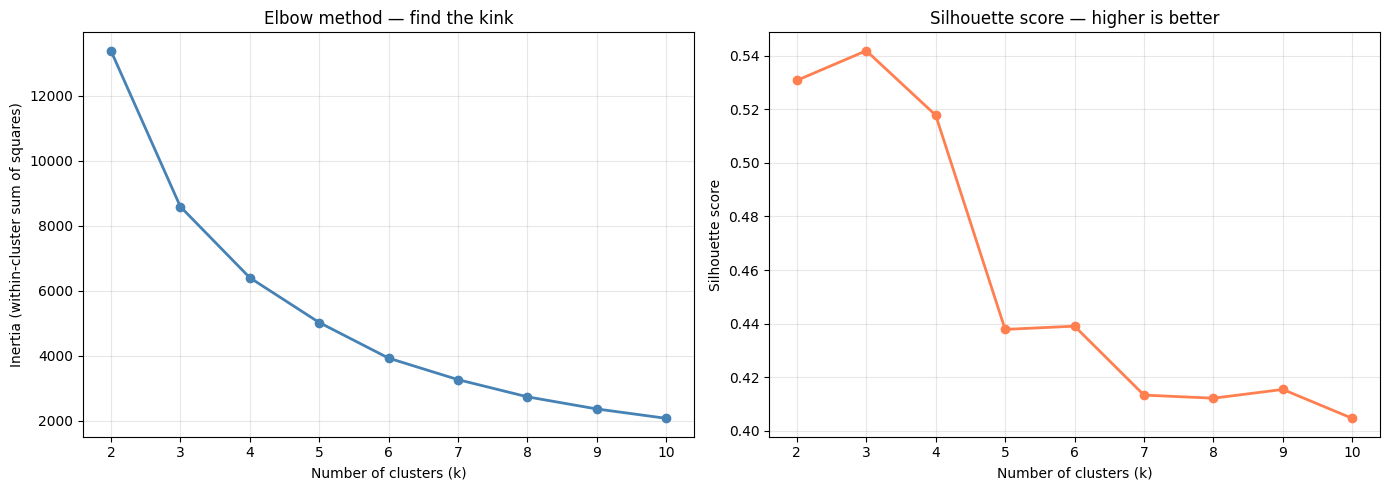

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow method — find the kink')
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, marker='o',color='coral', linewidth=2)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score — higher is better')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/kmeans_elbow_silhouette.png', dpi=100, bbox_inches='tight')
plt.show()

In [78]:
OPTIMAL_K=3
print(f"Selected k = {OPTIMAL_K}")

Selected k = 3


In [79]:
kmeans=KMeans(n_clusters=OPTIMAL_K,random_state=42,n_init=10)
cluster_labels=kmeans.fit_predict(X_pca)

df['Cluster']=cluster_labels

print("Cluster label distribution:")
print(df['Cluster'].value_counts().sort_index())
print(f"\nFinal silhouette score: {silhouette_score(X_pca, cluster_labels):.4f}")

Cluster label distribution:
Cluster
0    1678
1    2512
2      38
Name: count, dtype: int64

Final silhouette score: 0.5419


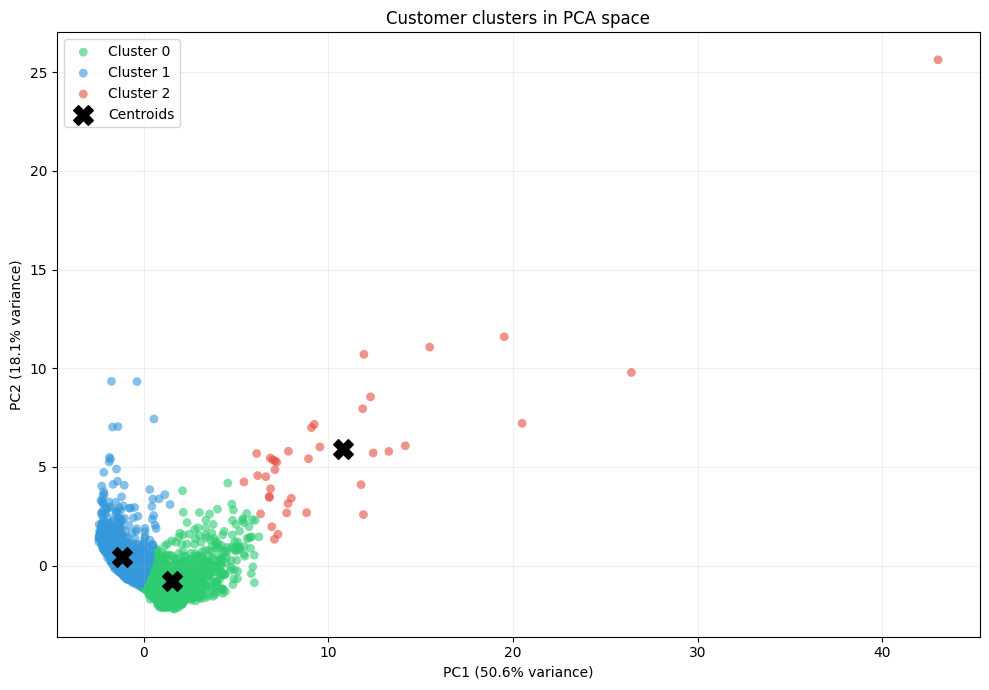

In [80]:
CLUSTER_COLORS = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c',3: '#f39c12', 4: '#9b59b6'}

plt.figure(figsize=(10, 7))

for cluster_id in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=CLUSTER_COLORS[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6, s=40, edgecolors='none'
    )
    
centroids=kmeans.cluster_centers_
plt.scatter(
    centroids[:,0], centroids[:,1],
    c='black',marker='X', s=200, zorder=5, label='Centroids'
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer clusters in PCA space')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/cluster_pca_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

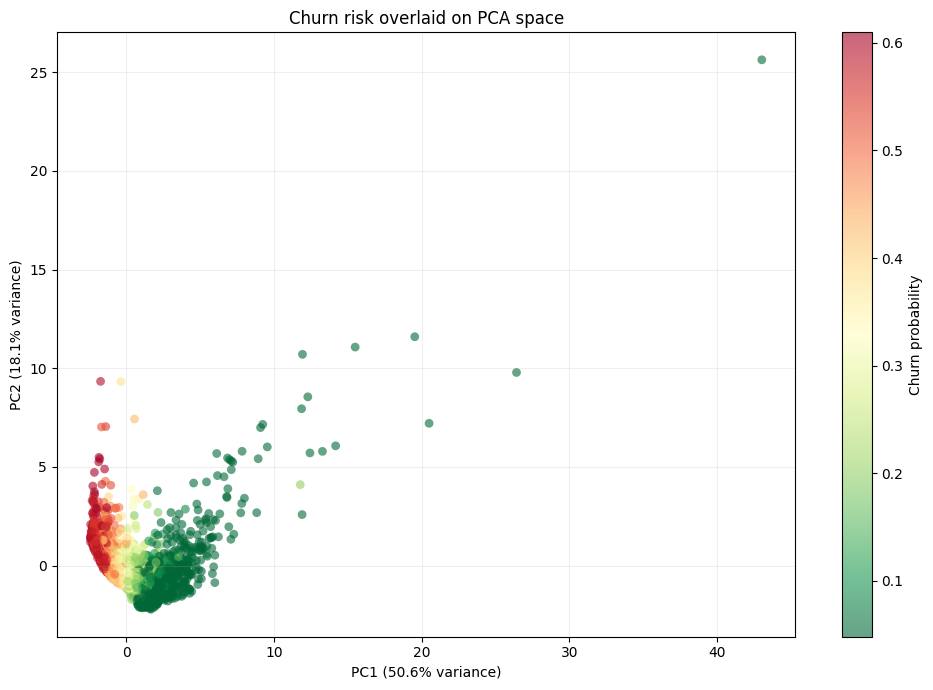

In [81]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['Churn_Probability'], cmap='RdYlGn_r',alpha=0.6, s=40, edgecolors='none'
)
plt.colorbar(scatter, label='Churn probability')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Churn risk overlaid on PCA space')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/cluster_churn_overlay.png', dpi=100, bbox_inches='tight')
plt.show()

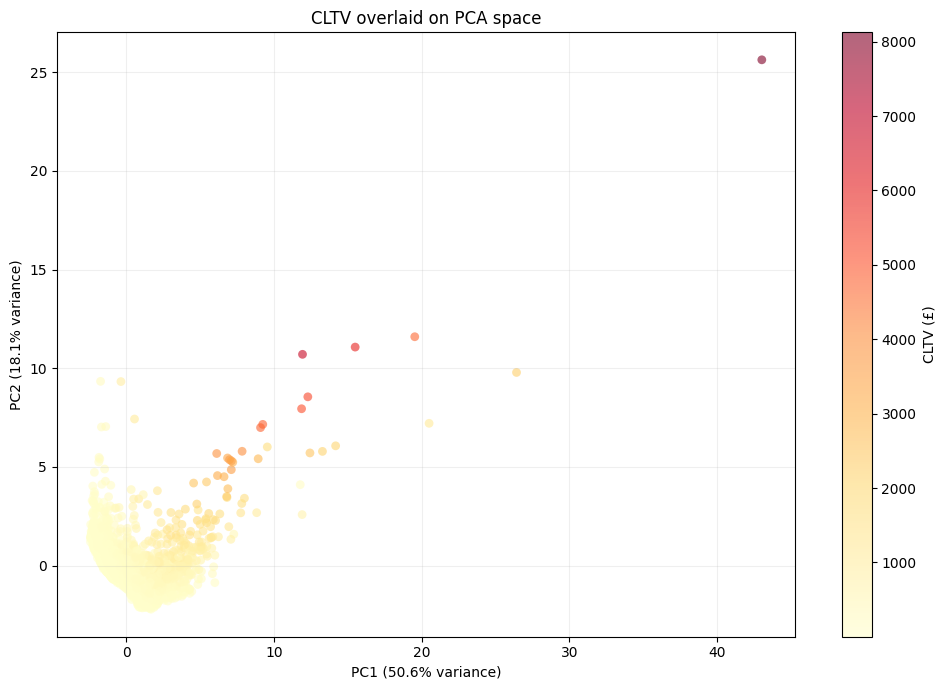

In [82]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['CLTV'], cmap='YlOrRd',alpha=0.6, s=40, edgecolors='none'
)
plt.colorbar(scatter, label='CLTV (£)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('CLTV overlaid on PCA space')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/cluster_cltv_overlay.png', dpi=100, bbox_inches='tight')
plt.show()

In [83]:
profile = df.groupby('Cluster').agg(
    Customer_Count=('CustomerID','count'),
    Avg_Recency =('Recency','mean'),
    Avg_Frequency= ('Frequency', 'mean'),
    Avg_Monetary = ('Monetary','mean'),
    Avg_CLTV = ('CLTV','mean'),
    Total_Revenue= ('Monetary','sum'),
    Avg_ChurnProb= ('Churn_Probability', 'mean'),
    Avg_UniqueProds= ('UniqueProducts','mean'),
    Avg_Lifespan = ('Lifespan','mean'),
).round(2)

profile['Revenue_Share_%'] =(profile['Total_Revenue'] / profile['Total_Revenue'].sum()*100).round(1)

print(profile.to_string())

         Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_CLTV  Total_Revenue  Avg_ChurnProb  Avg_UniqueProds  Avg_Lifespan  Revenue_Share_%
Cluster                                                                                                                                                  
0                  1678        30.84           6.70       2094.29    224.20     3514220.87           0.12           102.24        263.25             66.2
1                  2512       135.17           1.66        425.22     41.43     1068141.33           0.47            26.74         36.37             20.1
2                    38         5.32          49.03      19142.85   2972.10      727428.35           0.05           353.79        351.87             13.7


In [84]:
segment_cluster=(
    df.groupby(['Cluster','Segment']).size().reset_index(name='Count').sort_values(['Cluster','Count'],ascending=[True,False])
)

print("\nRFM segment composition per cluster:")
for cluster_id in sorted(df['Cluster'].unique()):
    sub = segment_cluster[segment_cluster['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(sub[['Segment','Count']].to_string(index=False))



RFM segment composition per cluster:

Cluster 0:
           Segment  Count
          Champion    868
   Needs Attention    364
    Loyal Customer    231
           At Risk    157
      New Customer     24
       Hibernating     15
Potential Loyalist     15
              Lost      4

Cluster 1:
           Segment  Count
              Lost    788
       Hibernating    672
           At Risk    294
      New Customer    278
    Loyal Customer    220
   Needs Attention    143
Potential Loyalist     84
          Champion     33

Cluster 2:
        Segment  Count
       Champion     37
Needs Attention      1


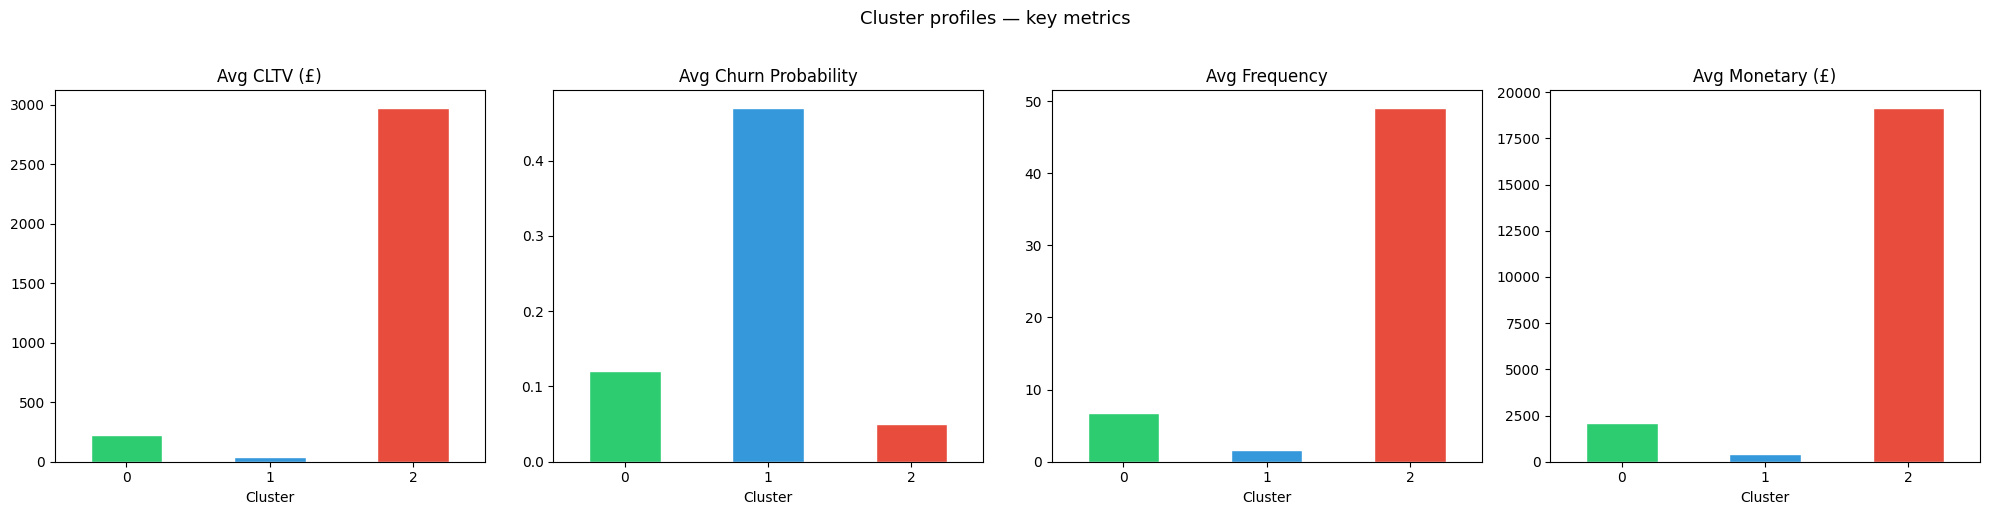

In [85]:
metrics = ['Avg_CLTV', 'Avg_ChurnProb', 'Avg_Frequency', 'Avg_Monetary']
titles = ['Avg CLTV (£)', 'Avg Churn Probability',
          'Avg Frequency', 'Avg Monetary (£)']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = [CLUSTER_COLORS[i] for i in sorted(df['Cluster'].unique())]

for ax, metric, title in zip(axes, metrics, titles):
    profile[metric].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Cluster')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Cluster profiles — key metrics', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/cluster_profiles.png', dpi=100, bbox_inches='tight')
plt.show()

In [86]:
cltv_rank=profile['Avg_CLTV'].rank(ascending=False).astype(int)
churn_rank=profile['Avg_ChurnProb'].rank(ascending=True).astype(int)

print("Cluster CLTV rank (1=highest):")
print(cltv_rank)
print("\nCluster Churn rank (1=lowest risk):")
print(churn_rank)

CLUSTER_NAMES={}
for cluster_id in sorted(df['Cluster'].unique()):
    cr=cltv_rank[cluster_id]
    churn_r=churn_rank[cluster_id]
    if cr==1:
        CLUSTER_NAMES[cluster_id]='High Value'
    elif cr==OPTIMAL_K:
        CLUSTER_NAMES[cluster_id]='Low Value'
    else:
        CLUSTER_NAMES[cluster_id]='Mid Value'
        
print("\nCluster names assigned:")
print(CLUSTER_NAMES)

df['Cluster_Name'] = df['Cluster'].map(CLUSTER_NAMES)

Cluster CLTV rank (1=highest):
Cluster
0    2
1    3
2    1
Name: Avg_CLTV, dtype: int32

Cluster Churn rank (1=lowest risk):
Cluster
0    2
1    3
2    1
Name: Avg_ChurnProb, dtype: int32

Cluster names assigned:
{0: 'Mid Value', 1: 'Low Value', 2: 'High Value'}


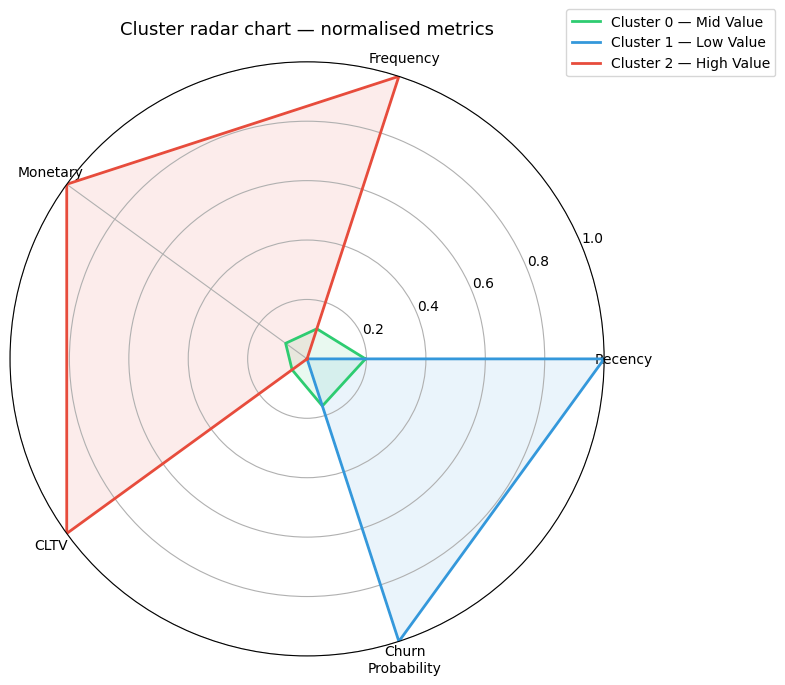

In [87]:
from matplotlib.patches import FancyArrowPatch

radar_metrics=['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary','Avg_CLTV', 'Avg_ChurnProb']
radar_labels = ['Recency', 'Frequency', 'Monetary','CLTV', 'Churn\nProbability']

profile_norm=profile[radar_metrics].copy()
for col in radar_metrics:
    col_max=profile_norm[col].max()
    col_min=profile_norm[col].min()
    if col_max>col_min:
        profile_norm[col]=(profile_norm[col]-col_min)/(col_max-col_min)
    else:
        profile_norm[col]=0.5

N=len(radar_metrics)
angles=[n/float(N)*2*np.pi for n in range(N)]
angles+=angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster_id in sorted(df['Cluster'].unique()):
    values = profile_norm.loc[cluster_id, radar_metrics].tolist()
    values += values[:1]
    name = CLUSTER_NAMES[cluster_id]
    ax.plot(angles, values, linewidth=2,
            color=CLUSTER_COLORS[cluster_id], label=f'Cluster {cluster_id} — {name}')
    ax.fill(angles, values, alpha=0.1, color=CLUSTER_COLORS[cluster_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=10)
ax.set_ylim(0, 1)
ax.set_title('Cluster radar chart — normalised metrics', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../outputs/cluster_radar.png', dpi=100, bbox_inches='tight')
plt.show()


In [88]:
import os
os.makedirs('../models', exist_ok=True)

# Save scaler
with open('../models/scaler_kmeans.pickle', 'wb') as f:
    pickle.dump(scaler_kmeans, f)

# Save PCA
with open('../models/pca.pickle', 'wb') as f:
    pickle.dump(pca, f)

# Save KMeans
with open('../models/kmeans.pickle', 'wb') as f:
    pickle.dump(kmeans, f)

# Save cluster name mapping
with open('../models/cluster_names.pickle', 'wb') as f:
    pickle.dump(CLUSTER_NAMES, f)

print("Saved:")
print("  models/scaler_kmeans.pickle")
print("  models/pca.pickle")
print("  models/kmeans.pickle")
print("  models/cluster_names.pickle")

Saved:
  models/scaler_kmeans.pickle
  models/pca.pickle
  models/kmeans.pickle
  models/cluster_names.pickle


In [89]:
df.to_csv('../outputs/customer_final.csv', index=False)

print("\nSaved: outputs/customer_final.csv")
print("Shape:", df.shape)
print("\nFinal columns:")
print(df.columns.tolist())


Saved: outputs/customer_final.csv
Shape: (4228, 27)

Final columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AOV', 'UniqueProducts', 'Lifespan', 'AvgDaysBetweenOrders', 'CLTV', 'CLTV_Tier', 'Churned', 'Log_Recency', 'Log_Frequency', 'Log_Monetary', 'Log_AOV', 'Log_CLTV', 'F_Score', 'M_Score', 'R_Score', 'RFM_Score', 'RFM_Label', 'Segment', 'Churn Probability', 'Churn_Probability', 'Churn_Risk', 'Cluster', 'Cluster_Name']


In [90]:
print("\n" + "="*70)
print("CLUSTERING SUMMARY")
print("="*70)
print(f"Method        : K-Means (k={OPTIMAL_K}) on 2-component PCA")
print(f"PCA variance  : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Silhouette    : {silhouette_score(X_pca, cluster_labels):.4f}")
print()
print(f"{'Cluster':<5} {'Name':<15} {'Customers':>10} "
      f"{'Avg CLTV':>10} {'Churn %':>9} {'Rev Share':>10}")
print("-"*70)
for cid in sorted(df['Cluster'].unique()):
    row = profile.loc[cid]
    print(f"{cid:<5} {CLUSTER_NAMES[cid]:<15} "
          f"{int(row['Customer_Count']):>10,} "
          f"£{row['Avg_CLTV']:>9,.0f} "
          f"{row['Avg_ChurnProb']*100:>8.1f}% "
          f"{row['Revenue_Share_%']:>9.1f}%")
print("="*70)


CLUSTERING SUMMARY
Method        : K-Means (k=3) on 2-component PCA
PCA variance  : 68.7%
Silhouette    : 0.5419

Cluster Name             Customers   Avg CLTV   Churn %  Rev Share
----------------------------------------------------------------------
0     Mid Value            1,678 £      224     12.0%      66.2%
1     Low Value            2,512 £       41     47.0%      20.1%
2     High Value              38 £    2,972      5.0%      13.7%
